# Feature Engineering 🔧
### Cancelamento de Serviços — Empresa de Saneamento

**Objetivo:** Construir o dataset analítico no nível de **ordem de serviço** (uma linha por ordem) com todas as features válidas para o modelo preditivo.

**Premissa fundamental:** A predição ocorre no momento da abertura da ordem (`DATA_REG`). Nenhuma feature pode usar informações geradas após esse instante.


# 📋 1. Setup e Carregamento

Nesta etapa, os dados brutos são carregados e os mesmos filtros de negócio do EDA são aplicados: polos 07/12/13 e serviços com indicadores de desempenho. O resultado é o dataset base sobre o qual as features serão construídas.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

FIGURES  = Path('../reports/figures')
RAW_PATH = Path('../data/raw/servicos_operacionais.csv')
PROCESSED_PATH = Path('../data/processed')
FIGURES.mkdir(parents=True, exist_ok=True)
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

STR_COLS = [
    'CODIGO', 'COD_POLO', 'COD_AREA_SERVICO', 'COD_SETOR_ABAST',
    'COD_BACIA_ESGOT', 'COD_MUNICIPIO', 'COD_SERVICO', 'COD_SERVICO_ETAPA',
    'COD_SERVICO_EXECUTADO', 'ID_SERVICO', 'ID_LIGACAO',
    'GRUPO_SERVICO_OPERACIONAL', 'GRUPO_SERVICO_195', 'PRIORI',
]
DATE_COLS = [
    'DATA_REG', 'DATAENT', 'DATA_CRIACAO_ETAPA',
    'DATA_INICIO_SERVICO', 'DATA_FIM_SERVICO',
]

# Carregamento — usar nrows=None para a base completa
df = pd.read_csv(RAW_PATH, dtype={col: str for col in STR_COLS}, nrows=500_000)
for col in DATE_COLS:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Limpeza básica
df = df[df['ID_LIGACAO'].notna()]
df = df[df['ID_LIGACAO'] != '000000000000000']
df = df[df['DATA_INICIO_SERVICO'].notna()]
if 'OBSERVACAO' in df.columns:
    df = df.drop(columns=['OBSERVACAO'])

# Filtros de negócio
POLOS_ALVO = ['07', '12', '13']
LIST_CODS  = [
    '1.010','1.020','1.030','1.040','1.044','1.050','1.060','1.070',
    '1.180','1.190','1.200','1.230','1.231','1.240','1.250','1.270',
    '1.280','1.450','1.470','1.500','1.501','1.510','1.511','1.515',
    '1.520','1.530','1.540','1.550','1.555','1.560','1.570','1.580',
    '1.590','1.601','1.602','1.603','1.604','1.605','1.608','1.620',
    '1.691','1.710','1.720','1.740','1.770','2.010','2.040','2.080',
    '2.090','2.200','2.210','2.220','2.230','2.240','2.250','2.260',
    '2.270','2.300','2.310','2.320','2.330','2.430','2.460','2.462','2.470'
]
df = df[df['COD_POLO'].isin(POLOS_ALVO)].copy()
df = df[df['COD_SERVICO_ETAPA'].isin(LIST_CODS)].copy()
df = df.dropna(subset=['COD_SERVICO_EXECUTADO','COD_BACIA_ESGOT',
                        'COD_SETOR_ABAST','COD_AREA_SERVICO'])

# Target
df['cancelado'] = df['COD_SERVICO_EXECUTADO'].str.startswith('3').astype(int)

print(f'Shape base filtrada: {df.shape}')
print(f'Taxa de cancelamento: {df["cancelado"].mean():.2%}')


Shape base filtrada: (54613, 20)
Taxa de cancelamento: 30.25%


💡 **Observação:**

O dataset base reproduz exatamente o estado final do EDA: **54.613 ordens** após filtros de polo, serviço e remoção de nulos. Cada linha representa uma ordem de serviço — esta é a granularidade correta para o modelo, que precisa decidir **por ordem**, não por ligação.


# ⏱️ 2. Features de Prazo e Serviço

Nesta etapa, são criadas features derivadas diretamente do tipo de serviço e do prazo contratual — ambos conhecidos no momento da abertura da ordem. `prazo_horas` já mostrou forte sinal na EDA (variação de 7% a 40% na taxa de cancelamento).


In [2]:
prazo_map = {}
for cod in ['1.010','1.020','1.030','1.050','1.060','1.070','1.180','1.190','1.250',
            '1.450','1.470','1.500','1.501','1.510','1.511','1.520','1.530','1.540',
            '1.550','1.560','1.570','1.580','1.590','1.605','1.620','1.770','2.010',
            '2.200','2.210','2.220','2.230','2.240','2.250','2.260','2.270','2.460','2.462']:
    prazo_map[cod] = 24
for cod in ['1.601','1.602','1.603','1.604','1.608','1.691']: prazo_map[cod] = 48
for cod in ['2.080']:                                          prazo_map[cod] = 72
for cod in ['1.515','1.555','2.430','2.470']:                  prazo_map[cod] = 96
for cod in ['1.040','1.270']:                                  prazo_map[cod] = 120
for cod in ['1.200','1.230','1.231','1.240','1.280','1.710','1.720','1.740',
            '2.040','2.090','2.300','2.310','2.320','2.330']:   prazo_map[cod] = 168
for cod in ['1.044']:                                          prazo_map[cod] = 240

df['prazo_horas'] = df['COD_SERVICO_ETAPA'].map(prazo_map)

# PRIORI já está em escala ordinal (1=alta, 4=baixa) — converter para int
df['priori_num'] = pd.to_numeric(df['PRIORI'], errors='coerce')

print('prazo_horas — distribuição:')
print(df['prazo_horas'].value_counts().sort_index())
print()
print('priori_num — distribuição:')
print(df['priori_num'].value_counts().sort_index())
print(f'Nulos em priori_num: {df["priori_num"].isna().sum()}')


prazo_horas — distribuição:
prazo_horas
24     44603
48       576
72       803
96      4664
120      254
168     3173
240      540
Name: count, dtype: int64

priori_num — distribuição:
priori_num
10    47284
20        2
21     2147
22     5180
Name: count, dtype: int64
Nulos em priori_num: 0


💡 **Observação:**

| Feature | Tipo | Valores | Observação |
|---------|------|---------|------------|
| `prazo_horas` | Numérica ordinal | 24, 48, 72, 96, 120, 168, 240 | Derivada deterministicamente do código de serviço |
| `priori_num` | Numérica ordinal | 1–4 | 1 = mais urgente; relação monotônica com cancelamento confirmada no EDA |

Ambas as features são **determinísticas no momento da abertura** — sem risco de leakage.


# 🕐 3. Features Temporais

Nesta etapa, são extraídas features do timestamp de abertura da ordem (`DATA_REG`). Dia da semana, mês e hora são conhecidos no momento da predição e mostraram variação relevante na taxa de cancelamento durante a EDA.


In [3]:
df['hora_abertura']   = df['DATA_REG'].dt.hour
df['dia_semana_num']  = df['DATA_REG'].dt.dayofweek   # 0=segunda, 6=domingo
df['mes']             = df['DATA_REG'].dt.month
df['fim_de_semana']   = (df['dia_semana_num'] >= 5).astype(int)
df['fora_horario_com'] = ((df['hora_abertura'] < 8) | (df['hora_abertura'] >= 18)).astype(int)

print('Taxa de cancelamento por fim_de_semana:')
print(df.groupby('fim_de_semana')['cancelado'].mean().mul(100).round(2))
print()
print('Taxa de cancelamento por fora_horario_comercial:')
print(df.groupby('fora_horario_com')['cancelado'].mean().mul(100).round(2))


Taxa de cancelamento por fim_de_semana:
fim_de_semana
0   29.6500
1   34.1500
Name: cancelado, dtype: float64

Taxa de cancelamento por fora_horario_comercial:
fora_horario_com
0   29.4700
1   36.0600
Name: cancelado, dtype: float64


💡 **Observação:**

| Feature | Tipo | Descrição |
|---------|------|----------|
| `hora_abertura` | Numérica (0–23) | Hora em que a ordem foi registrada |
| `dia_semana_num` | Numérica (0–6) | 0=segunda-feira, 6=domingo |
| `mes` | Numérica (1–12) | Mês de abertura da ordem |
| `fim_de_semana` | Binária | 1 se sábado ou domingo |
| `fora_horario_com` | Binária | 1 se abertura antes das 8h ou após as 18h |

As features binárias `fim_de_semana` e `fora_horario_com` condensam os padrões identificados na EDA em sinais diretos — úteis especialmente para modelos lineares.


# 📜 4. Features Históricas por Ligação

Nesta etapa, são construídas features comportamentais baseadas no **histórico da ligação** (`ID_LIGACAO`). A lógica central é: para cada ordem, calcular estatísticas usando **apenas as ordens anteriores** da mesma ligação.

A técnica utilizada é o `shift(1)` + `expanding()` dentro de cada grupo, após ordenação por `DATA_REG`. Isso garante que, no momento da abertura de cada ordem, o modelo só enxerga o que já aconteceu — sem leakage.

```
Ligação X:
  Ordem 1 (jan) → hist_n_ordens=0, hist_taxa_cancel=NaN
  Ordem 2 (fev) → hist_n_ordens=1, hist_taxa_cancel=0.0 ou 1.0 (baseado na ordem 1)
  Ordem 3 (mar) → hist_n_ordens=2, hist_taxa_cancel=média das ordens 1 e 2
```


In [4]:
# Ordenar por ligação e data de abertura — garante a janela temporal correta
df = df.sort_values(['ID_LIGACAO', 'DATA_REG']).reset_index(drop=True)

# ── Histórico de cancelamentos da ligação ────────────────────────────────
# shift(1): exclui a ordem atual do cálculo (anti-leakage)
# expanding(): considera todo o histórico disponível até aquele momento

grp = df.groupby('ID_LIGACAO')['cancelado']

df['hist_n_ordens']       = df.groupby('ID_LIGACAO').cumcount()  # ordens anteriores
df['hist_n_cancelamentos'] = grp.transform(lambda x: x.shift(1).expanding().sum())
df['hist_taxa_cancelamento'] = grp.transform(lambda x: x.shift(1).expanding().mean())

# ── Recência: dias desde a última ordem da ligação ───────────────────────
df['data_reg_anterior'] = df.groupby('ID_LIGACAO')['DATA_REG'].shift(1)
df['hist_recencia_dias'] = (
    (df['DATA_REG'] - df['data_reg_anterior']).dt.total_seconds() / 86400
)
df = df.drop(columns=['data_reg_anterior'])

# ── Reincidência: mesma natureza de serviço nos últimos 90 dias ─────────
# Identifica se a ligação já abriu a mesma categoria de serviço recentemente
def reincidencia_90d(sub):
    """Para cada linha, conta quantas ordens do mesmo grupo existem nos 90 dias anteriores."""
    resultado = []
    for i, row in sub.iterrows():
        janela = sub[
            (sub['DATA_REG'] < row['DATA_REG']) &
            (sub['DATA_REG'] >= row['DATA_REG'] - pd.Timedelta(days=90)) &
            (sub['GRUPO_SERVICO_OPERACIONAL'] == row['GRUPO_SERVICO_OPERACIONAL'])
        ]
        resultado.append(len(janela))
    return pd.Series(resultado, index=sub.index)

print('Calculando reincidência (pode demorar alguns minutos)...')
df['hist_reincidencia_90d'] = (
    df.groupby('ID_LIGACAO', group_keys=False)
    .apply(reincidencia_90d)
)

# ── Preencher NaN das primeiras ordens de cada ligação ───────────────────
# Primeira ordem de uma ligação: sem histórico → preencher com 0
df['hist_n_cancelamentos']    = df['hist_n_cancelamentos'].fillna(0)
df['hist_taxa_cancelamento']  = df['hist_taxa_cancelamento'].fillna(0)
df['hist_recencia_dias']      = df['hist_recencia_dias'].fillna(-1)  # -1 = sem histórico

print('Concluído.')
print(f"\nNulos restantes nas features históricas:")
hist_cols = ['hist_n_ordens','hist_n_cancelamentos','hist_taxa_cancelamento',
             'hist_recencia_dias','hist_reincidencia_90d']
print(df[hist_cols].isnull().sum())


Calculando reincidência (pode demorar alguns minutos)...


Concluído.

Nulos restantes nas features históricas:
hist_n_ordens             0
hist_n_cancelamentos      0
hist_taxa_cancelamento    0
hist_recencia_dias        0
hist_reincidencia_90d     0
dtype: int64


💡 **Observação:**

| Feature | Descrição | Primeira ordem da ligação |
|---------|-----------|---------------------------|
| `hist_n_ordens` | Qtd de ordens anteriores da ligação | 0 |
| `hist_n_cancelamentos` | Qtd de cancelamentos anteriores | 0 |
| `hist_taxa_cancelamento` | Proporção de cancelamentos anteriores | 0 |
| `hist_recencia_dias` | Dias desde a última ordem | -1 (sem histórico) |
| `hist_reincidencia_90d` | Ordens do mesmo grupo nos últimos 90 dias | 0 |

O valor `-1` para `hist_recencia_dias` na primeira ordem é intencional — é um sinal distinto de "nunca usou o serviço antes", diferente de uma recência real de 0 dias. Modelos baseados em árvore tratam isso naturalmente.

> **Validação anti-leakage:** `hist_taxa_cancelamento` usa `shift(1)` — a ordem atual **não entra** no cálculo da sua própria taxa histórica.


# ✅ 5. Validação e Dataset Final

Nesta etapa, o dataset de features é consolidado, validado contra leakage e salvo em parquet para uso no notebook de modelagem.


In [5]:
# Colunas que formam o dataset final de modelagem
FEATURE_COLS = [
    # Data de abertura — usada apenas para corte temporal no notebook de modelagem
    'DATA_REG',
    # Serviço e prazo
    'prazo_horas',
    'priori_num',
    # Temporais
    'hora_abertura',
    'dia_semana_num',
    'mes',
    'fim_de_semana',
    'fora_horario_com',
    # Categóricas — encoding feito dentro do pipeline de modelagem
    'GRUPO_SERVICO_OPERACIONAL',
    'COD_AREA_SERVICO',
    'COD_SERVICO_ETAPA',
    # Históricas por ligação
    'hist_n_ordens',
    'hist_n_cancelamentos',
    'hist_taxa_cancelamento',
    'hist_recencia_dias',
    'hist_reincidencia_90d',
]
TARGET_COL = 'cancelado'

df_model = df[FEATURE_COLS + [TARGET_COL]].copy()

print(f'Shape do dataset final: {df_model.shape}')
print(f'Taxa de cancelamento:   {df_model[TARGET_COL].mean():.2%}')
print(f'Nulos totais:           {df_model.isnull().sum().sum()}')
print()
print('Features e tipos:')
display(df_model.dtypes.to_frame('dtype'))


Shape do dataset final: (54613, 17)
Taxa de cancelamento:   30.25%
Nulos totais:           0

Features e tipos:


,dtype
DATA_REG,datetime64[ns]
prazo_horas,int64
priori_num,int64
hora_abertura,int32
dia_semana_num,int32
mes,int32
fim_de_semana,int64
fora_horario_com,int64
GRUPO_SERVICO_OPERACIONAL,object
COD_AREA_SERVICO,object


In [6]:
# Verificação anti-leakage: nenhuma coluna proibida pode estar no dataset
COLUNAS_PROIBIDAS = [
    'COD_SERVICO_EXECUTADO', 'DATA_FIM_SERVICO',
    'duracao_servico_min', 'atendido_no_prazo',
]
vazamento = [c for c in COLUNAS_PROIBIDAS if c in df_model.columns]
assert len(vazamento) == 0, f'LEAKAGE DETECTADO: {vazamento}'
print('✅ Nenhuma coluna com leakage detectada.')

# Estatísticas descritivas do dataset final
display(df_model.describe())


✅ Nenhuma coluna com leakage detectada.


,DATA_REG,prazo_horas,priori_num,hora_abertura,dia_semana_num,mes,fim_de_semana,fora_horario_com,hist_n_ordens,hist_n_cancelamentos,hist_taxa_cancelamento,hist_recencia_dias,hist_reincidencia_90d,cancelado
count,54613,54613.0000,54613.0000,54613.0000,54613.0000,54613.0000,54613.0000,54613.0000,54613.0000,54613.0000,54613.0000,54613.0000,54613.0000,54613.0000
mean,2019-03-24 05:44:46.907329536,42.0564,11.5710,12.2334,2.3592,6.3485,0.1345,0.1190,0.5692,0.1415,0.0913,11.0630,0.0538,0.3025
min,2018-04-01 08:38:01,24.0000,10.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-1.0000,0.0000,0.0000
25%,2018-09-19 14:43:45,24.0000,10.0000,10.0000,1.0000,4.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-1.0000,0.0000,0.0000
50%,2019-03-13 15:35:42,24.0000,10.0000,12.0000,2.0000,6.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-1.0000,0.0000,0.0000
75%,2019-09-17 17:20:04,24.0000,10.0000,15.0000,4.0000,9.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000
max,2020-04-27 13:35:30,240.0000,22.0000,23.0000,6.0000,12.0000,1.0000,1.0000,16.0000,8.0000,1.0000,734.9832,6.0000,1.0000
std,NaN,43.1928,3.9939,3.4086,1.7835,3.3816,0.3412,0.3238,0.9782,0.4299,0.2685,60.1938,0.2897,0.4594


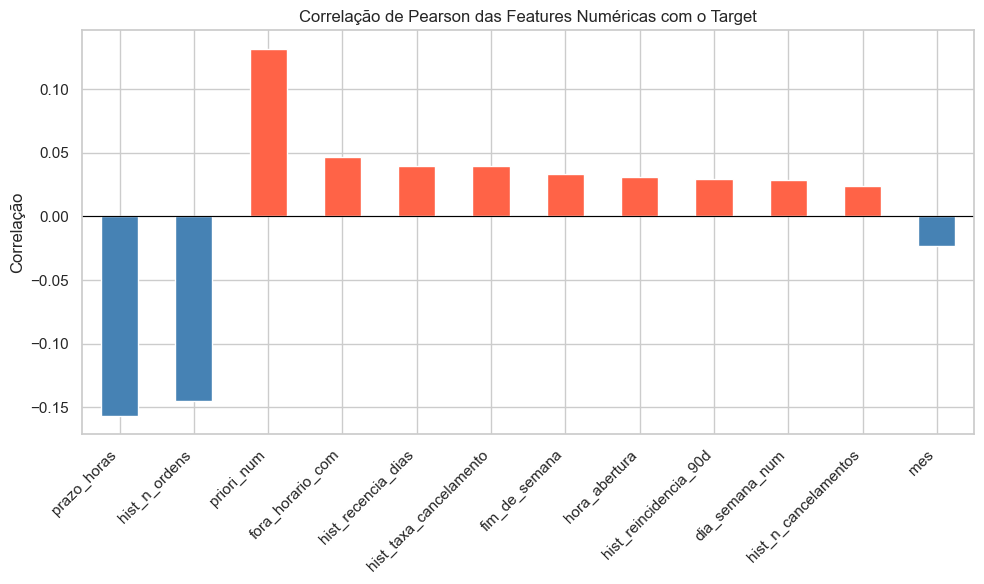

Top features correlacionadas com cancelamento:
prazo_horas              -0.1568
hist_n_ordens            -0.1446
priori_num                0.1316
fora_horario_com          0.0464
hist_recencia_dias        0.0399
hist_taxa_cancelamento    0.0396
fim_de_semana             0.0335
hora_abertura             0.0307
hist_reincidencia_90d     0.0291
dia_semana_num            0.0282


In [7]:
# Correlação das features numéricas com o target
# (categóricas são excluídas — serão codificadas no pipeline de modelagem)
num_cols = df_model.select_dtypes(include='number').columns.tolist()
corr = (
    df_model[num_cols].corr()[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr]
corr.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Correlação de Pearson das Features Numéricas com o Target')
ax.set_ylabel('Correlação')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/correlacao_features_target.png', dpi=120)
plt.show()

print('Top features correlacionadas com cancelamento:')
print(corr.head(10).to_string())


In [8]:
# Salvar dataset final em parquet
output_path = PROCESSED_PATH / 'features_modelo.parquet'
df_model.to_parquet(output_path, index=False)
print(f'Dataset salvo em: {output_path}')
print(f'Shape: {df_model.shape}')


Dataset salvo em: ..\data\processed\features_modelo.parquet
Shape: (54613, 17)


💡 **Observação:**

## Resumo das Features

| Feature | Grupo | Tipo | Sinal esperado |
|---------|-------|------|----------------|
| `prazo_horas` | Serviço | Numérica | Prazo curto → mais cancelamento |
| `priori_num` | Serviço | Ordinal | Prioridade alta (1) → mais cancelamento |
| `hora_abertura` | Temporal | Numérica | Fora do horário comercial → mais cancelamento |
| `dia_semana_num` | Temporal | Numérica | Fim de semana → mais cancelamento |
| `mes` | Temporal | Numérica | Sazonalidade mensal |
| `fim_de_semana` | Temporal | Binária | Sinal direto do padrão semanal |
| `fora_horario_com` | Temporal | Binária | Sinal direto do padrão horário |
| `GRUPO_SERVICO_OPERACIONAL` | Categórica | String | **Maior sinal da EDA (~50 pp)** — target encoding no pipeline |
| `COD_AREA_SERVICO` | Categórica | String | Variação geográfica (~30 pp) — target encoding no pipeline |
| `COD_SERVICO_ETAPA` | Categórica | String | Serviços 2.xxx com taxa > 50% — target encoding no pipeline |
| `hist_n_ordens` | Histórica | Numérica | Ligações antigas podem ter padrão diferente |
| `hist_n_cancelamentos` | Histórica | Numérica | Reincidência absoluta |
| `hist_taxa_cancelamento` | Histórica | Numérica | Propensão histórica da ligação |
| `hist_recencia_dias` | Histórica | Numérica | -1 = primeira ordem da ligação |
| `hist_reincidencia_90d` | Histórica | Numérica | Mesma categoria de serviço recente |

**Próximo passo:** Notebook `03_modeling.ipynb` — baseline, Random Forest, XGBoost e análise SHAP.
